<!-- Cabeçalho -->
<br />
<p align="center">

  <h1 align="center">Análise Espacial</h1>
  
</p>

## Introdução

Embora a análise nacional forneça uma visão geral da distribuição da população indígena, ela não evidencia as diferenças existentes entre as Grandes Regiões brasileiras. A dimensão espacial constitui um elemento fundamental para compreender a diversidade territorial do país e as distintas formas de ocupação do espaço pela população indígena. Nesse contexto, esta etapa amplia a análise para a escala regional, investigando como a população indígena se distribui entre Terras Indígenas e áreas externas, bem como entre áreas urbanas e rurais, permitindo identificar padrões recorrentes e diferenças regionais na organização espacial dessa população.

### Carregando dependências e a base de dados

Configurando o ambiente para análise de dados com as principais bibliotecas da stack:

In [ ]:
import sys, os
sys.path.append(os.path.abspath('../')) # Sobe um nível e adiciona ao path

from charts.thematic_maps import PlotMapas

import geopandas as gpd
from pathlib import Path


In [2]:
# Define o caminho para o diretório raiz do projeto
ROOT = Path.cwd().parent

# Carrega o GeoDataFrame dos estados a partir do arquivo Parquet
gdf_estados = gpd.read_parquet(
    ROOT / "data" / "geo" / "db_estados_geo.parquet"
)

# Carrega o GeoDataFrame das regiões a partir do arquivo Parquet
gdf_regioes = gpd.read_parquet(
    ROOT / "data" / "geo" / "db_regioes_geo.parquet"
)

# Instancia a classe PlotMapas com o GeoDataFrame dos estados e o diretório de saída para os mapas
mapas = PlotMapas(
    gdf=gdf_estados,
    diretorio_saida=ROOT / "outputs" / "figures",
)

## Como a população indígena está distribuída pelo território brasileiro?

O primeiro passo consiste em identificar os estados que concentram os maiores contingentes de população indígena segundo o Censo Demográfico de 2022. Para isso, utiliza-se um mapa coroplético, no qual a intensidade da cor representa a quantidade absoluta de indígenas em cada Unidade da Federação.

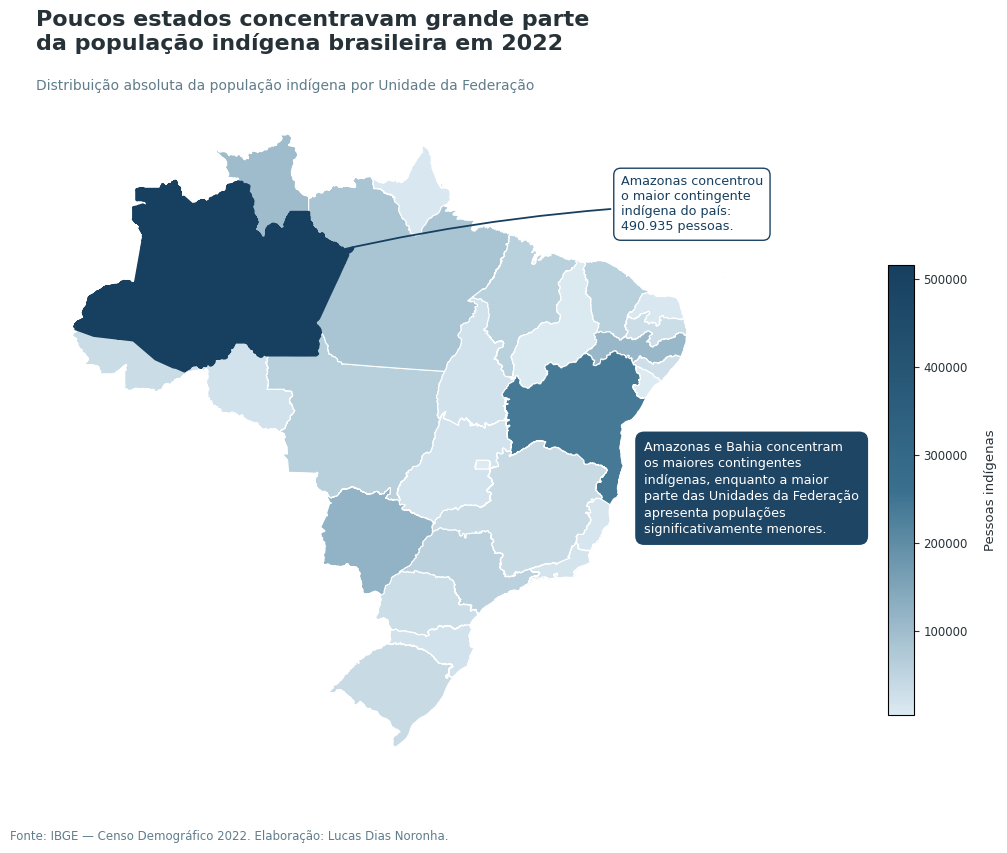

In [3]:
mapas.plot_populacao_indigena_2022()

In [4]:
# Exibe os 5 estados com maior população indígena em 2022
gdf_estados[
    ["NM_UF", "Indígenas 2022 Total"]
].nlargest(
    5,
    "Indígenas 2022 Total",
)

,NM_UF,Indígenas 2022 Total
18,Amazonas,490935
24,Bahia,229443
13,Mato Grosso do Sul,116469
20,Pernambuco,106646
25,Roraima,97668


### Resposta
O mapa evidencia que a população indígena brasileira estava distribuída de forma bastante desigual entre as Unidades da Federação. Embora houvesse registros em todo o território nacional, poucos estados concentravam contingentes muito superiores aos observados na maior parte do país.

O Amazonas apresentou o maior contingente indígena, com 490.935 pessoas, destacando-se de maneira expressiva em relação às demais UFs. A Bahia também apareceu entre os principais polos de concentração, mostrando que a distribuição não se restringia à Região Norte nem à Amazônia Legal. Estados como Mato Grosso do Sul, Pernambuco e Roraima também apresentaram contingentes relevantes, ainda que inferiores aos dois maiores destaques.

A leitura espacial revela, portanto, uma distribuição heterogênea: enquanto algumas Unidades da Federação reuniam parcelas expressivas da população indígena brasileira, grande parte dos estados apresentava contingentes consideravelmente menores. Esse resultado reforça que a presença indígena no Brasil possui ampla abrangência territorial, mas sua concentração absoluta varia intensamente entre as diferentes regiões do país.

É importante observar que este mapa apresenta valores absolutos. Por isso, ele permite identificar onde vivem os maiores contingentes indígenas, mas não informa ainda qual é o peso dessa população dentro do total de habitantes de cada estado. Uma Unidade da Federação pode apresentar um número absoluto menor e, ao mesmo tempo, possuir uma proporção indígena elevada em relação à sua população total.

## Quais estados apresentaram os maiores crescimentos percentuais da população indígena entre 2010 e 2022?

Nossa variável será:

$$Crescimento (\%) = \left( \frac{\text{População}_{2022} - \text{População}_{2010}}{\text{População}_{2010}} \right) \times 100$$

In [5]:
# Calcula o crescimento percentual da população indígena entre 2010 e 2022
gdf_estados["Crescimento percentual"] = (
    (
        gdf_estados["Indígenas 2022 Total"]
        - gdf_estados["Indígenas 2010 Total"]
    )
    / gdf_estados["Indígenas 2010 Total"]
) * 100

# Exibe os estados com maior crescimento percentual da população indígena entre 2010 e 2022
gdf_estados[
    [
        "NM_UF",
        "Indígenas 2010 Total",
        "Indígenas 2022 Total",
        "Crescimento percentual",
    ]
].sort_values(
    "Crescimento percentual",
    ascending=False,
)

,NM_UF,Indígenas 2010 Total,Indígenas 2022 Total,Crescimento percentual
9,Rio Grande do Norte,2597,11724,351.443974
24,Bahia,60120,229443,281.641717
7,Ceará,20697,56372,172.367976
18,Amazonas,183514,490935,167.519099
12,Piauí,2944,7202,144.633152
8,Goiás,8583,19517,127.391355
16,Acre,17578,31694,80.304927
20,Pernambuco,60995,106646,74.843840
25,Roraima,55922,97668,74.650406
21,Rondônia,13076,21146,61.716121


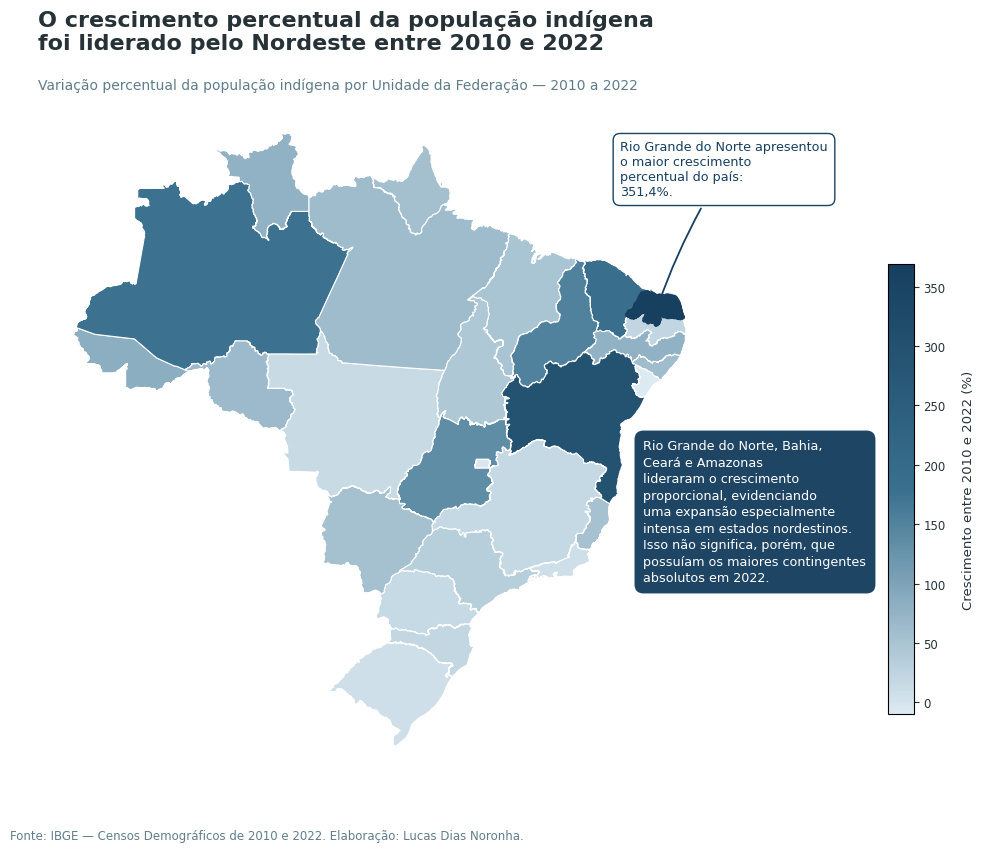

In [6]:
mapas.plot_crescimento_percentual()

### Resposta

O mapa evidencia que o crescimento percentual da população indígena ocorreu de forma bastante desigual entre as Unidades da Federação. Embora o aumento tenha sido observado na maior parte do país, sua intensidade variou significativamente entre os estados.

O Rio Grande do Norte registrou a maior expansão proporcional do período, passando de 2.597 pessoas indígenas em 2010 para 11.724 em 2022, o que representa um crescimento de 351,4%. Em seguida aparecem Bahia (281,6%), Ceará (172,4%) e Amazonas (167,5%).

Observa-se ainda um padrão espacial importante: entre os estados que apresentaram os maiores crescimentos percentuais, três pertencem à Região Nordeste, indicando que a expansão da população indígena foi particularmente intensa nessa região ao longo do período analisado.

É importante destacar que crescimento percentual e população absoluta representam medidas distintas. Enquanto o Rio Grande do Norte liderou o crescimento proporcional, o Amazonas permaneceu como o estado com o maior contingente indígena em números absolutos. Assim, este mapa evidencia a intensidade relativa das transformações ocorridas entre os Censos Demográficos de 2010 e 2022, e não a quantidade total de pessoas indígenas em cada Unidade da Federação.

## Quais estados ganharam ou perderam participação na população indígena brasileira entre 2010 e 2022?

### 1. Total da População Indígena Nacional

$$\text{Total}_{t} = \sum_{i=1}^{N} P_{i,t}$$

Onde $P_{i,t}$ representa a população indígena do estado $i$ no ano $t \in \{2010, 2022\}$, e $N$ é o total de estados.

---

### 2. Participação Percentual do Estado no Total Nacional

$$\text{Participação}_{i,t} (\%) = \left( \frac{P_{i,t}}{\text{Total}_{t}} \right) \times 100$$

---

### 3. Mudança na Participação Percentual (Variação em Pontos Percentuais)

$$\Delta \text{Participação}_{i} = \text{Participação}_{i,2022} (\%) - \text{Participação}_{i,2010} (\%)$$

In [7]:
total_2010 = gdf_estados["Indígenas 2010 Total"].sum() # Calcula o total de população indígena em 2010

total_2022 = gdf_estados["Indígenas 2022 Total"].sum() # Calcula o total de população indígena em 2022

# Calcula a participação percentual da população indígena de cada estado em relação ao total nacional para os anos de 2010 e 2022
gdf_estados["Participação 2010 (%)"] = (
    gdf_estados["Indígenas 2010 Total"]
    / total_2010
) * 100

# Calcula a participação percentual da população indígena de cada estado em relação ao total nacional para os anos de 2010 e 2022
gdf_estados["Participação 2022 (%)"] = (
    gdf_estados["Indígenas 2022 Total"]
    / total_2022
) * 100

# Calcula a mudança na participação percentual da população indígena de cada estado entre 2010 e 2022
gdf_estados["Mudança participação"] = (
    gdf_estados["Participação 2022 (%)"]
    - gdf_estados["Participação 2010 (%)"]
)

# Exibe os estados com maior mudança na participação percentual da população indígena entre 2010 e 2022
gdf_estados[
    [
        "NM_UF",
        "Participação 2010 (%)",
        "Participação 2022 (%)",
        "Mudança participação",
    ]
].sort_values(
    "Mudança participação",
    ascending=False,
)

,NM_UF,Participação 2010 (%),Participação 2022 (%),Mudança participação
18,Amazonas,20.460533,28.966519,8.505986
24,Bahia,6.702961,13.537770,6.834809
7,Ceará,2.307571,3.326104,1.018532
9,Rio Grande do Norte,0.289547,0.691748,0.402201
8,Goiás,0.956945,1.151557,0.194612
12,Piauí,0.328236,0.424938,0.096702
16,Acre,1.959825,1.870033,-0.089791
22,Amapá,0.826275,0.668737,-0.157538
21,Rondônia,1.457883,1.247672,-0.210211
2,Espírito Santo,1.068661,0.850230,-0.218431


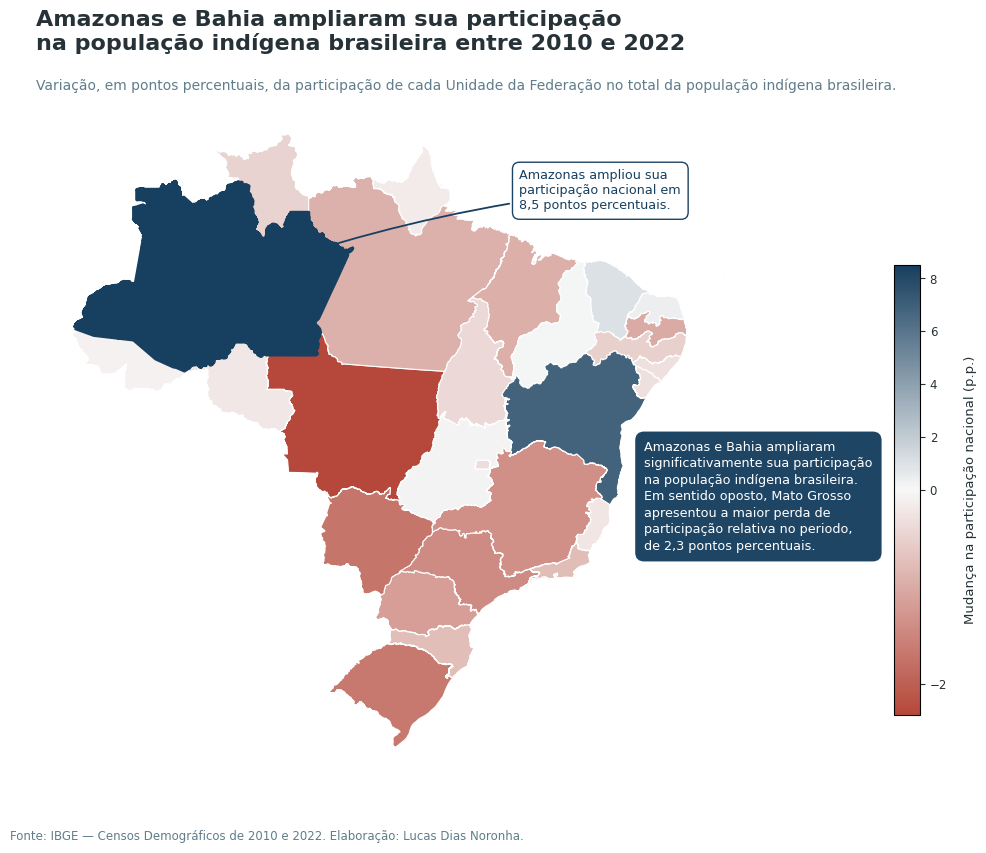

In [8]:
mapas.plot_mudanca_participacao()

### Resposta
A participação das Unidades da Federação na população indígena brasileira passou por mudanças significativas entre os Censos Demográficos de 2010 e 2022. Embora a população indígena tenha aumentado em grande parte do país, esse crescimento ocorreu em ritmos distintos, alterando a importância relativa de alguns estados na composição do total nacional.

O Amazonas foi o estado que mais ampliou sua participação, passando de 20,5% para 29,0% da população indígena brasileira, um ganho de 8,5 pontos percentuais. A Bahia apresentou a segunda maior expansão, elevando sua participação de 6,7% para 13,5%, equivalente a um acréscimo de 6,8 pontos percentuais. Esses resultados indicam que ambos concentraram uma parcela significativamente maior da população indígena nacional em 2022.

Em sentido oposto, estados como Mato Grosso, Mato Grosso do Sul, Rio Grande do Sul e São Paulo perderam participação relativa. Isso não significa, necessariamente, que suas populações indígenas diminuíram, mas sim que cresceram em ritmo inferior ao observado nos estados que lideraram a expansão nacional. O Mato Grosso, por exemplo, apresentou a maior perda de participação, reduzindo sua representatividade em 2,3 pontos percentuais.

Assim, o mapa evidencia uma reorganização da distribuição da população indígena brasileira entre 2010 e 2022, marcada pelo fortalecimento da participação de alguns estados, especialmente Amazonas e Bahia, e pela redução relativa da importância de outros na composição do total nacional.

## Como a população se distribui entre as regiões?

In [9]:
# Cria um GeoDataFrame com a população indígena total por região em 2022
regioes = (
    gdf_estados
    .dissolve(
        by="NM_REGIAO",
        aggfunc={
            "Indígenas 2022 Total": "sum",
        },
    )
    .reset_index()
)

regioes

,NM_REGIAO,geometry,Indígenas 2022 Total
0,Centro-oeste,"POLYGON ((-55.04062 -23.98082, -55.04429 -23.9...",200153
1,Nordeste,"MULTIPOLYGON (((-46.01369 -10.24884, -46.01772...",529128
2,Norte,"MULTIPOLYGON (((-60.80596 -13.65584, -60.81007...",753780
3,Sudeste,"MULTIPOLYGON (((-48.03811 -25.35732, -48.03819...",123434
4,Sul,"MULTIPOLYGON (((-53.27272 -32.92798, -53.31016...",88341


In [10]:
# Exibe a população indígena total por região em 2022
(
    regioes
    .groupby("NM_REGIAO")["Indígenas 2022 Total"]
    .sum()
    .sort_values(ascending=False)
)

NM_REGIAO
Norte           753780
Nordeste        529128
Centro-oeste    200153
Sudeste         123434
Sul              88341
Name: Indígenas 2022 Total, dtype: int64

### 1. Total Nacional da População Indígena (2022)

$$\text{Total}_{2022} = \sum_{r=1}^{R} P_{r, 2022}$$

Onde $P_{r, 2022}$ representa a população indígena da região $r$, e $R$ é o total de regiões do país ($R = 5$).

---

### 2. Participação Percentual da Região no Total Nacional (2022)

$$\text{Participação}_{r, 2022} (\%) = \left( \frac{P_{r, 2022}}{\text{Total}_{2022}} \right) \times 100$$

In [11]:
# Calcula o total da população indígena em 2022 para todas as regiões
total = regioes["Indígenas 2022 Total"].sum()

# Calcula a participação percentual da população indígena de cada região em relação ao total nacional para o ano de 2022
regioes["Participação (%)"] = (
    regioes["Indígenas 2022 Total"]
    / total
) * 100

# Exibe as regiões com maior participação percentual da população indígena em 2022
regioes[
    [
        "NM_REGIAO",
        "Indígenas 2022 Total",
        "Participação (%)",
    ]
].sort_values(
    "Participação (%)",
    ascending=False,
)

,NM_REGIAO,Indígenas 2022 Total,Participação (%)
2,Norte,753780,44.475100
1,Nordeste,529128,31.220012
0,Centro-oeste,200153,11.809579
3,Sudeste,123434,7.282947
4,Sul,88341,5.212363


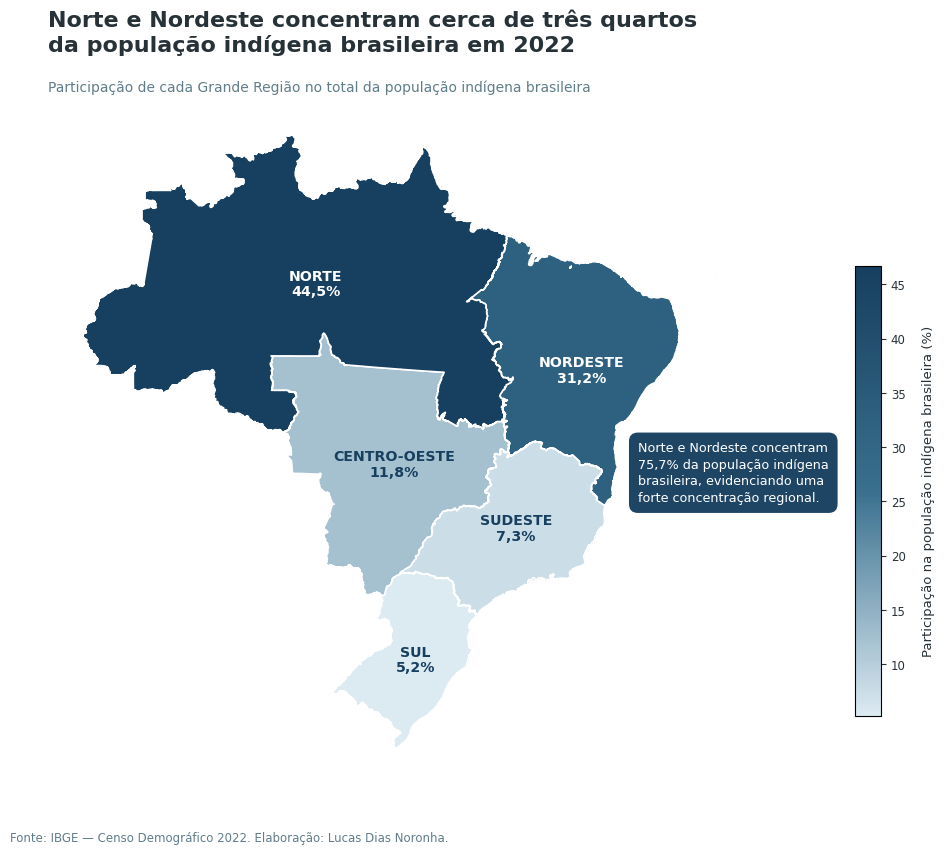

In [12]:
mapas.plot_distribuicao_regional()

### Resposta
A população indígena brasileira apresenta uma distribuição regional bastante concentrada. Em 2022, a Região Norte reuniu 44,5% de toda a população indígena do país, consolidando-se como a principal área de concentração. Em seguida, a Região Nordeste respondeu por 31,2% do total nacional. Juntas, essas duas regiões concentraram 75,7% da população indígena brasileira, evidenciando que a presença indígena no país possui uma forte concentração territorial.

As demais regiões apresentaram participações significativamente menores. O Centro-Oeste representou 11,8% da população indígena nacional, enquanto o Sudeste e o Sul responderam por 7,3% e 5,2%, respectivamente. Esses resultados demonstram que, embora a população indígena esteja presente em todas as Grandes Regiões, sua distribuição ocorre de forma desigual, com predominância expressiva nas regiões Norte e Nordeste.

## Conclusão

A análise espacial demonstra que a população indígena brasileira não se distribui de maneira homogênea pelo território nacional. Os maiores contingentes concentram-se em poucos estados, especialmente Amazonas e Bahia, enquanto o crescimento proporcional foi mais intenso em parte do Nordeste entre 2010 e 2022. Essas mudanças alteraram a participação relativa de algumas Unidades da Federação no total nacional, mas mantiveram uma forte concentração regional. Em síntese, os resultados indicam que a dinâmica recente da população indígena brasileira é caracterizada por desigualdades espaciais persistentes, com predominância das regiões Norte e Nordeste.